### Concepto de bootstrap

En estadística y machine learning, bootstrapping es una técnica de remuestreo que permite estimar la distribución de un estadístico sin necesidad de supuestos fuertes sobre la población.

¿Cómo funciona?
- Se toma una muestra original de tamaño $n$
- Se generan múltiples muestras con reemplazo del mismo tamaño $n$
- Se calcula el estadístico de interés (media, mediana, varianza, etc.) en cada muestra.
- Se usa la distribución de estos estadísticos para estimar intervalos de confianza o la variabilidad del modelo.


In [2]:
# Ejemplo
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')


df = pd.read_csv('housing.csv')
del df['ocean_proximity']

In [6]:
# Tomar un row aleatorio
df.sample(2)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
7045,-118.04,33.94,31.0,3808.0,670.0,2430.0,660.0,4.6250,173900.0
13498,-117.32,34.14,32.0,1691.0,353.0,1457.0,329.0,1.8438,66600.0


In [2]:
# Crear dataser aleatorio


In [10]:
# Crear dataser aleatorio, permitiendo remplazo
X_remplazo = df['median_house_value'].head(10)

In [12]:
X_remplazo

0    452600.0
1    358500.0
2    352100.0
3    341300.0
4    342200.0
5    269700.0
6    299200.0
7    241400.0
8    226700.0
9    261100.0
Name: median_house_value, dtype: float64

In [18]:
X_remplazo.sample(10, replace=True)

1    358500.0
7    241400.0
2    352100.0
5    269700.0
8    226700.0
8    226700.0
7    241400.0
8    226700.0
1    358500.0
7    241400.0
Name: median_house_value, dtype: float64

In [47]:
# Bootrstrap es entonces una técnica para crear datasets ficticios
promedios = []
for i in range(1, 10000):
    promedios.append(df['median_house_value'].sample(len(df), replace=True).median())

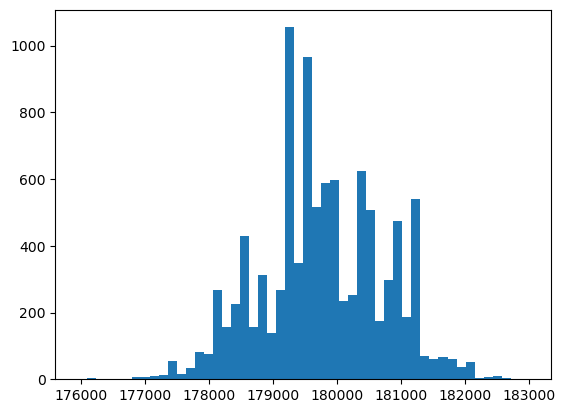

In [48]:
plt.hist(promedios, bins=50)
plt.show()

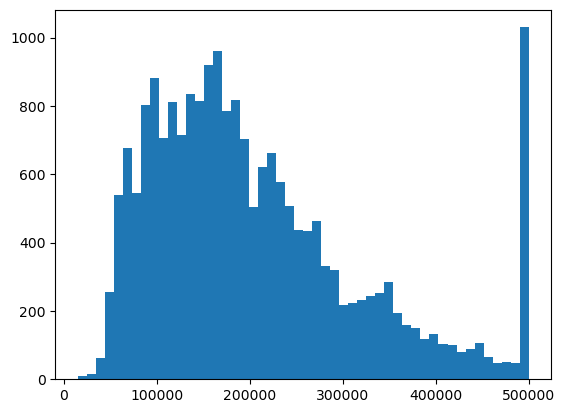

In [28]:
plt.hist(df.median_house_value, bins=50)
plt.show()

In [4]:
# Podemos hacer esto muchas veces y ver el histograma


## Teorema central del limite, el promedio de los promedios tiene una distribución normal 

# 📘 Derivación del Error Estándar de la Media

Sea $ X_1, X_2, \dots, X_n$ una muestra aleatoria simple, **i.i.d.**, proveniente de una población con:

$$
\mathbb{E}[X_i] = \mu, \quad \operatorname{Var}(X_i) = \sigma^2 < \infty
$$

Definimos la **media muestral** como:

$$
\bar{X} = \frac{1}{n} \sum_{i=1}^n X_i
$$

---


## 2️⃣ Varianza de la media muestral

Sabemos que \( X_i \) son **independientes**, por lo que las covarianzas se anulan.

$$
\operatorname{Var}(\bar{X})
= \operatorname{Var}\!\left(\frac{1}{n}\sum_{i=1}^n X_i\right)
= \frac{1}{n^2}\operatorname{Var}\!\left(\sum_{i=1}^n X_i\right)
$$

Como la varianza de una suma de variables independientes es la suma de sus varianzas:

$$
\operatorname{Var}\!\left(\sum_{i=1}^n X_i\right)
= \sum_{i=1}^n \operatorname{Var}(X_i)
= n\sigma^2
$$

Sustituyendo:

$$
\operatorname{Var}(\bar{X}) = \frac{1}{n^2}(n\sigma^2) = \frac{\sigma^2}{n}
$$

---

## 3️⃣ Definición del Error Estándar

El **error estándar** (SE) de la media es la desviación estándar de su distribución muestral:

$$
\operatorname{SE}(\bar{X}) = \sqrt{\operatorname{Var}(\bar{X})}
= \sqrt{\frac{\sigma^2}{n}}
= \frac{\sigma}{\sqrt{n}}
$$


In [41]:
## Calcula el error estandard
df.median_house_value.sem()

803.2199058796549

In [42]:
np.std(promedios)

804.0126948932714

In [43]:
# Cota inferior
np.mean(promedios) - 2 * np.std(promedios)


205242.65364872295

In [44]:
# Cota superior
np.mean(promedios) + 2 * np.std(promedios)

208458.70442829604

In [50]:
np.quantile(promedios, 0.95)

181300.0

In [51]:
np.quantile(promedios, 0.05)

178200.0

## Crea un intervalo de confianza de la media de las casas, al 95%

## Crea otro bootstrap de las casas, pero ahora de la mediana

### No es normal, solo el promedio de los promedios es normal

In [7]:
# Podemos obtener estadísticas aun así


### ¿Cuál es la probabilidad de que la mediana sea menor a 180000?

### ¿Cuál es la probabilidad de que la mediana sea mayor a 182000?

### Bootstrap nos permite calcular este tipo de cosas, distribuciones teorícas de un estadístico que no sea la media

### Caso 1, ceea una regresión lineal y dime un intervalo de confianza del R2

In [52]:
from sklearn import linear_model
from sklearn.metrics import r2_score, roc_auc_score

In [53]:
X = pd.get_dummies(df)
X = df.dropna()
target = 'median_house_value'
y = X[target]
del X[target]

In [56]:
model = linear_model.LinearRegression()
model.fit(X, y)
predicciones = model.predict(X)
r2_score(y_pred=predicciones, y_true=y)

0.6369116857335635

In [62]:
## Bootstrap
r2_sample = []
for i in range(1, 1000):
    model = linear_model.LinearRegression()
    # leo
    df = pd.read_csv('housing.csv')
    # Resampleo
    df = df.sample(len(df), replace=True)
    df = pd.get_dummies(df)
    # limpio
    X = pd.get_dummies(df)
    X = X.dropna()
    target = 'median_house_value'
    y = X[target]
    del X[target]
    # Mdoelo
    model.fit(X, y)
    predicciones = model.predict(X)
    r2_sample.append(r2_score(y_pred=predicciones, y_true=y))

In [64]:
np.quantile(r2_sample, 0.05)

0.6379451738818681

In [65]:
np.quantile(r2_sample, 0.95)

0.6554318570810644

### Caso 2, clasificación

In [67]:
df = pd.read_csv('titanic.csv')
df = df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1)
df = pd.get_dummies(df)
del df['Sex_female']
df['Age'] = df['Age'].fillna(df.Age.mean())
target = 'Survived'



In [69]:
# Bootstrap
auc_reample = []
for i in range(1,1000):
    df_bootstraped = df.sample(len(df), replace=True)
    model = linear_model.LogisticRegression()
    X = df_bootstraped.drop(target, axis=1)
    y = df_bootstraped[target]
    model.fit(X, y)
    # 
    probabilidades = model.predict_proba(X)[:,1]
    auc_reample.append(roc_auc_score(y_score=probabilidades, y_true=y))

In [70]:
np.quantile(auc_reample, 0.05)

0.8380231901589752

In [71]:
np.quantile(auc_reample, 0.95)

0.8812554560503031

## ¿Cual es la probabilidad que el AUC sea mayor que 0.9